In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/sample_submission.csv


In [2]:
#train_identity = pd.read_csv('../input/ieee-fraud-detection/train_identity.csv')
train_transaction = pd.read_csv('../input/ieee-fraud-detection/train_transaction.csv')
#test_identity = pd.read_csv('../input/ieee-fraud-detection/test_identity.csv')
test_transaction = pd.read_csv('../input/ieee-fraud-detection/test_transaction.csv')

In [3]:
# Helper functions
# 1. For calculating % na values in  columns
def percent_na(df):
    percent_missing = df.isnull().sum() * 100 / len(df)
    missing_value_df = pd.DataFrame({'column_name': percent_missing.index,
                                 'percent_missing': percent_missing.values})
    return missing_value_df
# 2. For plotting grouped histograms 
def sephist(col):
    yes = train_transaction[train_transaction['isFraud'] == 1][col]
    no = train_transaction[train_transaction['isFraud'] == 0][col]
    return yes, no

In [4]:
# Helper function for column value details

def column_value_freq(df,sel_col,cum_per):
    dfpercount = pd.DataFrame(columns=['col_name','num_values_99'])
    for col in sel_col:
        col_value = df[col].value_counts(normalize=True)
        colpercount = pd.DataFrame({'value' : col_value.index,'per_count' : col_value.values})
        colpercount['cum_per_count'] = colpercount['per_count'].cumsum()
        if len(colpercount.loc[colpercount['cum_per_count'] < cum_per,] ) < 2:
            num_col_99 = len(colpercount.loc[colpercount['per_count'] > (1- cum_per),])
        else:
            num_col_99 = len(colpercount.loc[colpercount['cum_per_count']< cum_per,] )
        dfpercount=dfpercount.append({'col_name': col,'num_values_99': num_col_99},ignore_index = True)
    dfpercount['unique_values'] = df[sel_col].nunique().values
    dfpercount['unique_value_to_num_values_99_ratio'] = 100 * (dfpercount.num_values_99/dfpercount.unique_values)
    dfpercount['percent_missing'] = percent_na(df[sel_col])['percent_missing'].round(3).values
    return dfpercount

def column_value_details(df,sel_col,cum_per):
    dfpercount = pd.DataFrame(columns=['col_name','values_'+str(round(cum_per,2)),'values_'+str(round(1-cum_per,2))])
    for col in sel_col:
        col_value = df[col].value_counts(normalize=True)
        colpercount = pd.DataFrame({'value' : col_value.index,'per_count' : col_value.values})
        colpercount['cum_per_count'] = colpercount['per_count'].cumsum()
        if len(colpercount.loc[colpercount['cum_per_count'] < cum_per,] ) < 2:
            values_freq = colpercount.loc[colpercount['per_count'] > (1- cum_per),'value'].tolist()
        else:
            values_freq = colpercount.loc[colpercount['cum_per_count']< cum_per,'value'].tolist() 
        values_less_freq =  [item for item in colpercount['value'] if item not in values_freq]
        dfpercount=dfpercount.append({'col_name': col,'values_'+str(round(cum_per,2)) : values_freq ,'values_'+str(round(1-cum_per,2)): values_less_freq},ignore_index = True)
    return dfpercount

In [5]:
def col_unique(df,cols):
    dat=df[cols].nunique()
    sns.set(rc={'figure.figsize':(8,4)})
    plot=sns.barplot(x=dat.index,y=dat.values)
    for p in plot.patches:
        plot.annotate("%d" % p.get_height(), (p.get_x() + p.get_width() / 2., p.get_height()),
               ha='center', va='top', fontsize=12, color='black', xytext=(0, 20),
                 textcoords='offset points')
    plot=plot.set(xlabel='Column ',ylabel= 'Number of unique values')

Of the 394 features/columns in the train_transaction data 15 columns begin in C .
The officaila explanation of these columns is.

*C1-C14: counting, such as how many addresses are found to be associated with the payment card, etc. The actual meaning is masked.*

All C columns are of the numeric data type and summary is as below

In [6]:
Ccols= train_transaction.columns[train_transaction.columns.str.startswith('C')]
train_transaction[Ccols].describe()

,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14
count,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000
mean,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215
std,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,1.000000
75%,3.000000,3.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,2.000000,0.000000,2.000000,0.000000,12.000000,2.000000
max,4685.000000,5691.000000,26.000000,2253.000000,349.000000,2253.000000,2255.000000,3331.000000,210.000000,3257.000000,3188.000000,3188.000000,2918.000000,1429.000000


The graph below shows number of unique values in each of the C Columns as blue bars.Orange bar shows the number of  unique values in 96.5% of the data in each of the columns. The difference between the two bars is a measure of how distributed the data is across the range of unique values in the column. 

Red line is the percentage of missing values in  the columns.

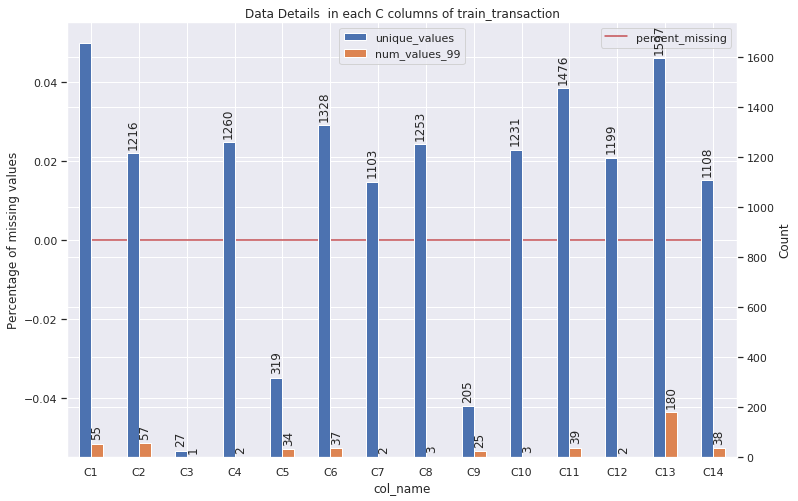

In [7]:
col_freq = column_value_freq(train_transaction,Ccols,0.965)
sns.set(rc={'figure.figsize':(12,8)})
plot=col_freq.plot(x='col_name',y='percent_missing',color='r')
plot.set(ylabel='Percentage of missing values')
ax1=plot.twinx()
#Dcol_freq['percent_missing'].plot(secondary_y=True, color='k', marker='o')
#Dcol_freq['unique_value_to_num_values_99_ratio'].plot(secondary_y=True, color='r', marker='o')
plot1=col_freq.plot(x='col_name',y=['unique_values','num_values_99'],ax=ax1,kind='bar')
for p in plot1.patches[1:]:
    h = p.get_height()
    x = p.get_x()+p.get_width()/2.
    if h != 0:
        plot1.annotate("%g" % p.get_height(), xy=(x,h), xytext=(0,4), rotation=90, 
                   textcoords="offset points", ha="center", va="bottom")
plot1.set(ylabel='Count')
plot= plot.set(title='Data Details  in each C columns of train_transaction')


**Interesting to  note that none of the C columns have missing values**.

Across the range of values in each of the column  few values make up 96.5% of data in each of the columns compared to total unique values.


Let's also look at test_transaction data set to verify whether the distribution of values are similiar

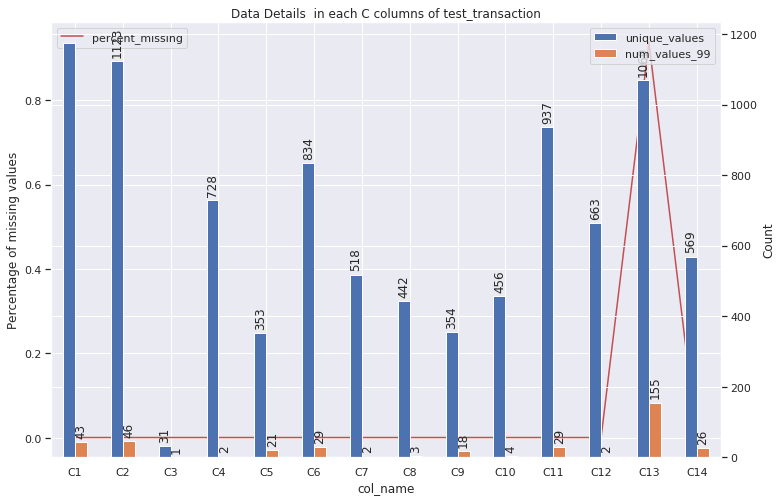

In [8]:
col_freq = column_value_freq(test_transaction,Ccols,0.965)
sns.set(rc={'figure.figsize':(12,8)})
plot=col_freq.plot(x='col_name',y='percent_missing',color='r')
plot.set(ylabel='Percentage of missing values')
ax1=plot.twinx()
#Dcol_freq['percent_missing'].plot(secondary_y=True, color='k', marker='o')
#Dcol_freq['unique_value_to_num_values_99_ratio'].plot(secondary_y=True, color='r', marker='o')
plot1=col_freq.plot(x='col_name',y=['unique_values','num_values_99'],ax=ax1,kind='bar')
for p in plot1.patches[1:]:
    h = p.get_height()
    x = p.get_x()+p.get_width()/2.
    if h != 0:
        plot1.annotate("%g" % p.get_height(), xy=(x,h), xytext=(0,4), rotation=90, 
                   textcoords="offset points", ha="center", va="bottom")
plot1.set(ylabel='Count')
plot= plot.set(title='Data Details  in each C columns of test_transaction')

Interestingly C13 has more than 90% missing values and C14 has 20% missing values.  These features are potentially candidates to be dropped while building models.

**Unique Card Identifier**

It looks a combination of Card =features card1-card 6 and C columns will help us to identify the unique payment cards (cards with unique 15 or 16 digit card numbers).

After exploring various combiantion of features a combination  of ['card1' ,'card2','card3','card4','card5','card6', 'addr1','C1','C2' ,'C3', 'C4','C5','C6','C7','C8','C9','C10','C11']  shows some interesting patterns

In [9]:
# cards=['card1','card2','card3','card4','card5','card6']
# by = cards+['addr1']+Ccols.tolist()
# group1=train_transaction.groupby(by,as_index=False)['TransactionID'].count()
# group1.sort_values(by='TransactionID',ascending=False).head(30)

In [10]:
# pd.options.display.max_columns = None
# Dcols =train_transaction.columns[train_transaction.columns.str.startswith('D')]
# select=train_transaction.columns[1:55]
# group1_details=pd.merge(group1,train_transaction[select],on=by,how='right')
# #group1_details.sort_values(by=['TransactionID','TransactionDT'],ascending=False)
# #group1_details[(group1_details.card1==16075) & (group1_details.TransactionID==60)]
# group1_details[(group1_details[['D1','D2','D3']].notnull().all(1)) & (group1_details.TransactionID>30 )].head(5)
# group1_details[(group1_details.card1==1342) & (group1_details.TransactionID==39)]

In [11]:
pd.options.display.max_columns = None
by=['card1','card2','card3','card4','card5','card6','addr1','C1','C2','C3','C4','C5','C6','C7','C8','C9','C10','C11']
cards_addr1_Ccolsgroup_count=train_transaction.groupby(by,as_index=False)['TransactionID'].count()
cards_addr1_Ccolsgroup_count.rename(columns={"TransactionID": "Count"},inplace=True)
cards_addr1_Ccolsgroup_count.sort_values(by='Count',ascending=False).head(30)

,card1,card2,card3,card4,card5,card6,addr1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,Count
193239,15775,481.0,150.0,mastercard,102.0,credit,330.0,5.0,3.0,0.0,3.0,0.0,0.0,0.0,8.0,0.0,3.0,5.0,1013
156395,12695,490.0,150.0,visa,226.0,debit,325.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,750
110131,9500,321.0,150.0,visa,226.0,debit,204.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,676
211948,17188,321.0,150.0,visa,226.0,debit,299.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,624
211974,17188,321.0,150.0,visa,226.0,debit,299.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,484
57842,6019,583.0,150.0,visa,226.0,credit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,451
198382,16132,111.0,150.0,visa,226.0,debit,299.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,432
111577,9500,321.0,150.0,visa,226.0,debit,272.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,406
212009,17188,321.0,150.0,visa,226.0,debit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,390
105115,9112,250.0,150.0,visa,226.0,debit,441.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,374


In [12]:
print('Total number of groups: ',len(cards_addr1_Ccolsgroup_count))
print('Average number of transaction per group: ',len(train_transaction)/len(cards_addr1_Ccolsgroup_count))

Total number of groups:  228120
Average number of transaction per group:  2.5887252323338594


Taking as sample details of transactions with card1 =9885

In [13]:
cards_addr1_Ccolsgroup_count[cards_addr1_Ccolsgroup_count.card1==9885].sort_values(by='Count',ascending=False).head(30)

,card1,card2,card3,card4,card5,card6,addr1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,Count
116990,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,66
117028,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64
116998,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,21
117017,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,1.0,18
117003,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,13
117035,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,3.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,12
116997,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,9
116987,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,9
117025,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,8
116989,9885,481.0,150.0,mastercard,117.0,debit,264.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,7


In [14]:
select=train_transaction.columns[0:55]
cards_addr1_Ccolsgroup_details=pd.merge(cards_addr1_Ccolsgroup_count,train_transaction[select],on=by,how='left')
#cards_addr1_Ccolsgroup_details.sort_values(by=['TransactionID','TransactionDT'],ascending=True)

In [15]:
pd.options.display.max_rows = None
cards_addr1_Ccolsgroup_details[(cards_addr1_Ccolsgroup_details.card1==9885) & (cards_addr1_Ccolsgroup_details.Count==64) ]

,card1,card2,card3,card4,card5,card6,addr1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,Count,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
259627,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,2990351,0,154685,295.0,W,87.0,NaN,NaN,gmail.com,NaN,0.0,4.0,1.0,143.0,92.0,0.0,187.0,0.0,NaN,NaN,NaN,NaN,25.0,NaN,NaN,NaN,NaN,187.0,T,F,F,M0,F,T,F,F,F
259628,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3005538,0,497391,70.0,W,87.0,NaN,NaN,gmail.com,NaN,0.0,4.0,1.0,147.0,96.0,4.0,191.0,4.0,NaN,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,191.0,NaN,NaN,NaN,M0,F,T,NaN,NaN,NaN
259629,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3005554,0,497588,87.0,W,87.0,18.0,NaN,gmail.com,NaN,0.0,4.0,1.0,147.0,96.0,0.0,191.0,0.0,NaN,NaN,NaN,NaN,29.0,191.0,NaN,NaN,NaN,191.0,T,T,T,M0,F,T,NaN,NaN,NaN
259630,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3005576,0,498015,59.0,W,87.0,18.0,NaN,NaN,NaN,0.0,4.0,1.0,147.0,96.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,191.0,191.0,NaN,NaN,NaN,191.0,T,T,T,M0,F,T,NaN,NaN,NaN
259631,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3115937,0,2568318,241.0,W,87.0,18.0,NaN,gmail.com,NaN,0.0,5.0,1.0,171.0,120.0,24.0,215.0,24.0,NaN,NaN,NaN,NaN,215.0,215.0,NaN,NaN,NaN,215.0,T,T,T,M0,F,T,NaN,NaN,NaN
259632,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3198716,0,4911732,92.0,W,87.0,NaN,NaN,gmail.com,NaN,0.0,5.0,1.0,198.0,147.0,27.0,242.0,27.0,NaN,NaN,NaN,NaN,242.0,NaN,NaN,NaN,NaN,242.0,NaN,NaN,NaN,M0,F,T,NaN,NaN,NaN
259633,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3198732,0,4912047,92.0,W,87.0,18.0,NaN,gmail.com,NaN,0.0,5.0,1.0,198.0,147.0,0.0,242.0,0.0,NaN,NaN,NaN,NaN,80.0,242.0,NaN,NaN,NaN,242.0,T,T,T,M0,F,T,F,F,T
259634,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3214711,0,5398069,315.0,W,87.0,18.0,NaN,gmail.com,NaN,1.0,6.0,1.0,204.0,153.0,6.0,248.0,6.0,NaN,NaN,NaN,NaN,86.0,248.0,NaN,NaN,NaN,248.0,T,T,T,M0,F,T,NaN,NaN,NaN
259635,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3232776,0,5853529,335.0,W,87.0,18.0,NaN,gmail.com,NaN,1.0,6.0,1.0,209.0,158.0,5.0,253.0,5.0,NaN,NaN,NaN,NaN,91.0,253.0,NaN,NaN,NaN,253.0,T,T,T,M0,F,T,NaN,NaN,NaN
259636,9885,481.0,150.0,mastercard,117.0,debit,264.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,64,3232786,0,5853818,335.0,W,87.0,18.0,NaN,gmail.com,NaN,1.0,6.0,1.0,209.0,158.0,0.0,253.0,0.0,NaN,NaN,NaN,NaN,91.0,253.0,NaN,NaN,NaN,253.0,T,T,T,M0,F,T,F,F,T


From the above data for card  with  card1 = 9885 and number of transactions during the 6 month period = 64 it can easily be seen that D3 column is the difference in number of days for  succesive transaction values of D1 and D2.

D5 values are almost same as D3 . But where D4 is null D5 is also null which means D5 is the difference in days of successive D4 values

D1,D2,D4,D11,D15 are days from some card events as their values increase with time. D4 ,D11 and D15 appears to be the same value but D11 has some nulls. D10 values don't follow the time series and need further analysis.

The increase in the values of D1,D2 ,D4 ,D11 and D15 corresponds with increase in days of the TransactionDT values.

The difference between the value of D1 between the first and last transaction in this group is 174 days corresponding t a 6 month period.

from the above this set of values appear to be  transactions of a specific card during the 6 month period.

**Hence it's safe to assume that the combination of the features 'card1','card2','card3','card4','card5','card6', 'addr1', 'C1','C2','C3','C4','C5','C6','C7','C8','C9','C10'and 'C11' can  uniquely identify the credit card.**

There seems to be a few cases where the D3 value is noth edifference in days between succesive row. On case is where the d1 value is 236 and D2 value is 185 . D3 is 4 for this row . But the previous row D1& D2s value are 209 and 158. Hence instead of 4 the D3 value should have been 27 . So it looks like a row of values with D1=232 and D2=181 has missed out

In [16]:
train_transaction[(train_transaction.card1==9885) & (train_transaction.D2==181.0) ]

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
313747,3300747,0,7825476,250.0,W,9885,NaN,NaN,NaN,NaN,NaN,264.0,87.0,NaN,NaN,gmail.com,NaN,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,8.0,1.0,232.0,181.0,23.0,276.0,23.0,NaN,NaN,NaN,NaN,114.0,276.0,NaN,NaN,NaN,276.0,T,T,T,M0,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1184.0,0.0,0.0,280.0,0.0,0.0,0.0,0.0,0.0,904.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,2.0,1.0,0.0,0.0,0.0,6.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1499.0,0.0,0.0,595.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,904.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The above row is the missing one and since it had null values for card2-card 6 it was not included in our grouping.

This throws up the possibility of imputing missing values in card2- card6 based on the feature groupings we identified as payment card identifier.


**Exploring D Columns further**

The plot below shows the data distribution in D columns 

In [17]:
Dcols= train_transaction.columns[train_transaction.columns.str.startswith('D')]

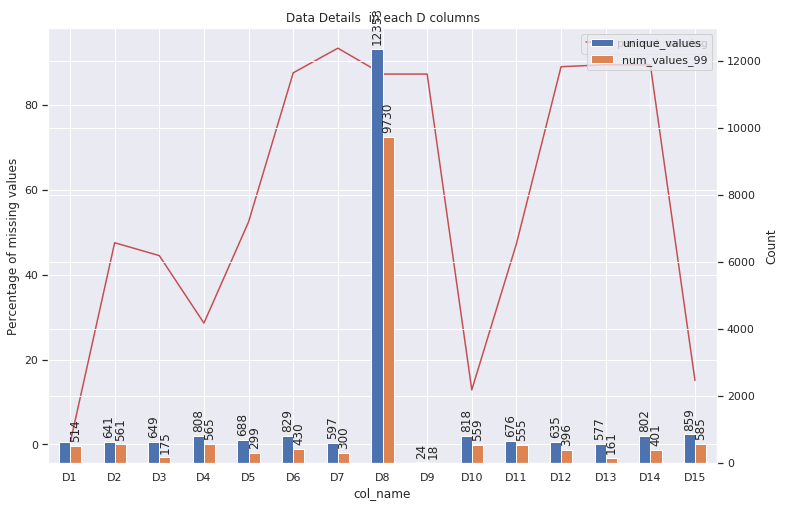

In [18]:
col_freq = column_value_freq(train_transaction,Dcols,0.965)
sns.set(rc={'figure.figsize':(12,8)})
plot=col_freq.plot(x='col_name',y='percent_missing',color='r')
plot.set(ylabel='Percentage of missing values')
ax1=plot.twinx()
#Dcol_freq['percent_missing'].plot(secondary_y=True, color='k', marker='o')
#Dcol_freq['unique_value_to_num_values_99_ratio'].plot(secondary_y=True, color='r', marker='o')
plot1=col_freq.plot(x='col_name',y=['unique_values','num_values_99'],ax=ax1,kind='bar')
for p in plot1.patches[1:]:
    h = p.get_height()
    x = p.get_x()+p.get_width()/2.
    if h != 0:
        plot1.annotate("%g" % p.get_height(), xy=(x,h), xytext=(0,4), rotation=90, 
                   textcoords="offset points", ha="center", va="bottom")
plot1.set(ylabel='Count')
plot= plot.set(title='Data Details  in each D columns')

From the above there is a fair uniform distribution of values in Dcolumns and these are truly numerical columns. histogram of data other than 0 and nulls are shown in the plot below.

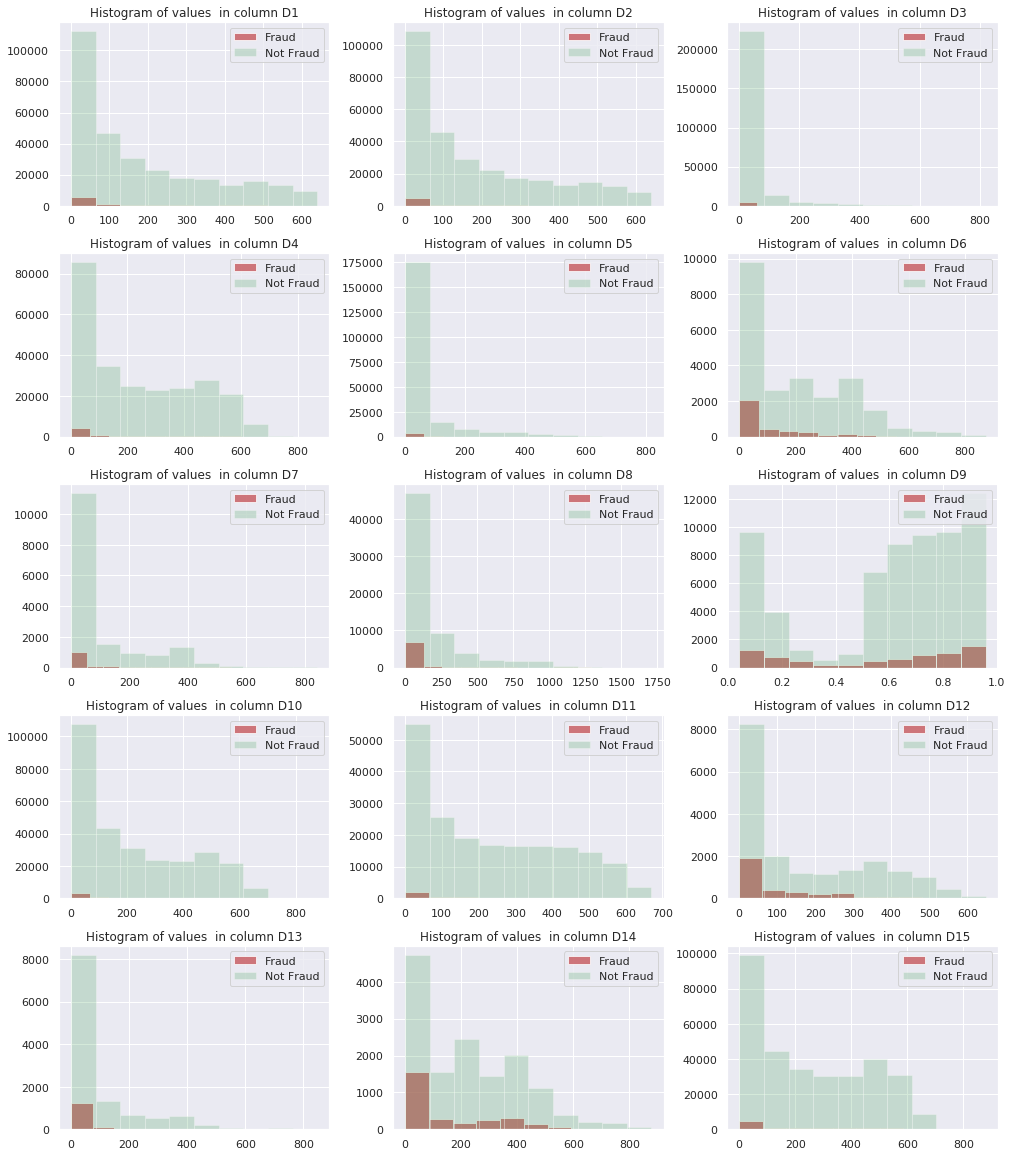

In [19]:
np.warnings.filterwarnings('ignore')
sns.set(rc={'figure.figsize':(14,16)})
for num, alpha in enumerate(Dcols):
    plt.subplot(5,3,num+1)
    yes = train_transaction[(train_transaction['isFraud'] == 1)][alpha]
    no = train_transaction[(train_transaction['isFraud'] == 0) ][alpha]
    plt.hist(yes[yes>0], alpha=0.75, label='Fraud', color='r')
    plt.hist(no[no>0], alpha=0.25, label='Not Fraud', color='g')
    plt.legend(loc='upper right')
    plt.title('Histogram of values  in column ' + str(alpha) )
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

From the above histogram D6,D7,D8,D12,D13,D14 seems to be number of days from some card event date .In any case thes columns have close to 90% null values. D9 is the day fraction of D8. This is confirmed by sample of data below.

In [20]:
cards_addr1_Ccolsgroup_details[(cards_addr1_Ccolsgroup_details[['D6','D7']].notnull().all(1)) & (cards_addr1_Ccolsgroup_details.Count >10)].head(30)

,card1,card2,card3,card4,card5,card6,addr1,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,Count,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9
4466,1333,170.0,150.0,visa,195.0,credit,204.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,11,3014555,0,690579,300.0,R,87.0,NaN,23.0,comcast.net,comcast.net,0.0,1.0,1.0,0.0,NaN,NaN,374.0,374.0,374.0,374.0,NaN,NaN,374.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15410,1724,583.0,150.0,visa,226.0,credit,184.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,18,3120818,0,2669942,75.0,R,87.0,NaN,NaN,hotmail.com,anonymous.com,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,379.0,379.0,78.875000,0.875000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15412,1724,583.0,150.0,visa,226.0,credit,184.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,18,3154955,0,3605679,100.0,R,87.0,NaN,4.0,anonymous.com,embarqmail.com,0.0,1.0,1.0,0.0,NaN,NaN,383.0,383.0,383.0,383.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,383.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15903,1724,583.0,150.0,visa,226.0,credit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,173,3087220,0,2018202,100.0,H,87.0,NaN,NaN,outlook.com,gmail.com,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15904,1724,583.0,150.0,visa,226.0,credit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,173,3087222,0,2018369,100.0,H,87.0,NaN,NaN,outlook.com,gmail.com,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.333333,0.333333,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15905,1724,583.0,150.0,visa,226.0,credit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,173,3087257,0,2023299,100.0,H,87.0,NaN,NaN,outlook.com,gmail.com,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.416666,0.416666,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15953,1724,583.0,150.0,visa,226.0,credit,299.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,173,3239429,0,6030373,100.0,R,87.0,NaN,NaN,att.net,aol.com,0.0,1.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.791666,0.791666,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16192,1724,583.0,150.0,visa,226.0,credit,315.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,73,3109951,0,2413152,150.0,R,87.0,NaN,1762.0,yahoo.com,anonymous.com,0.0,1.0,1.0,0.0,NaN,NaN,369.0,369.0,369.0,369.0,68.916664,0.916666,369.0,NaN,NaN,NaN,NaN,369.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16215,1724,583.0,150.0,visa,226.0,credit,315.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,73,3335365,0,8601150,150.0,H,87.0,NaN,NaN,gmail.com,gmail.com,0.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,394.541656,0.541666,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16216,1724,583.0,150.0,visa,226.0,credit,315.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,73,3335369,0,8601241,150.0,H,87.0,NaN,NaN,gmail.com,gmail.com,0.0,1.0,1.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,394.541656,0.541666,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Exploring C Columns further**

The table below shows for each column the values that make 96.5% of data in each column(values_0.99) and values that make the remaining 1% data in (values_0.01)

In [21]:
pd.options.display.max_colwidth =300
Ccol_details=column_value_details(train_transaction,Ccols,0.965)
num_values_96 =[]
for i in range(len(Ccol_details)):
    num_values_96.append(len(Ccol_details['values_0.96'][i]))
Ccol_details['num_values_96'] = num_values_96
Ccol_details

,col_name,values_0.96,values_0.04,num_values_96
0,C1,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 0.0, 20.0, 21.0, 22.0, 24.0, 117.0, 110.0, 111.0, 121.0, 126.0, 123.0, 25.0, 127.0, 125.0, 118.0, 116.0, 114.0, 101.0, 109.0, 120.0, 113.0, 130.0, 129.0, 102.0, 128.0, 104.0, 23.0, 107.0, 10...","[142.0, 124.0, 139.0, 100.0, 143.0, 136.0, 112.0, 103.0, 133.0, 131.0, 106.0, 144.0, 140.0, 26.0, 27.0, 96.0, 137.0, 132.0, 115.0, 148.0, 146.0, 99.0, 145.0, 94.0, 28.0, 141.0, 147.0, 152.0, 97.0, 98.0, 150.0, 93.0, 91.0, 155.0, 92.0, 82.0, 87.0, 151.0, 40.0, 89.0, 30.0, 84.0, 29.0, 153.0, 36.0,...",55
1,C2,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 0.0, 21.0, 23.0, 101.0, 94.0, 104.0, 102.0, 111.0, 100.0, 97.0, 106.0, 98.0, 115.0, 24.0, 105.0, 107.0, 113.0, 95.0, 114.0, 109.0, 119.0, 96.0, 112.0, 116.0, 117.0, 120.0, 99.0, 90.0, ...","[121.0, 103.0, 124.0, 28.0, 93.0, 88.0, 87.0, 91.0, 131.0, 85.0, 129.0, 25.0, 128.0, 125.0, 33.0, 92.0, 134.0, 84.0, 135.0, 36.0, 81.0, 86.0, 31.0, 133.0, 83.0, 132.0, 127.0, 30.0, 130.0, 143.0, 137.0, 140.0, 139.0, 82.0, 32.0, 144.0, 142.0, 138.0, 34.0, 136.0, 27.0, 29.0, 141.0, 80.0, 79.0, 145...",57
2,C3,[0.0],"[1.0, 2.0, 3.0, 4.0, 16.0, 9.0, 11.0, 5.0, 13.0, 14.0, 10.0, 8.0, 12.0, 15.0, 7.0, 17.0, 6.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 18.0]",1
3,C4,"[0.0, 1.0]","[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 9.0, 10.0, 8.0, 12.0, 11.0, 16.0, 15.0, 17.0, 13.0, 14.0, 20.0, 18.0, 52.0, 21.0, 19.0, 30.0, 83.0, 24.0, 70.0, 51.0, 23.0, 39.0, 91.0, 22.0, 92.0, 88.0, 35.0, 47.0, 37.0, 34.0, 25.0, 55.0, 31.0, 87.0, 58.0, 28.0, 41.0, 29.0, 84.0, 75.0, 46.0, 57.0, 54.0, 49.0, 33....",2
4,C5,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 15.0, 14.0, 16.0, 117.0, 17.0, 99.0, 116.0, 102.0, 121.0, 108.0, 107.0, 98.0, 118.0, 113.0, 19.0, 100.0, 104.0, 18.0, 105.0, 111.0]","[110.0, 119.0, 103.0, 21.0, 109.0, 112.0, 114.0, 122.0, 106.0, 120.0, 22.0, 96.0, 127.0, 123.0, 130.0, 115.0, 132.0, 97.0, 94.0, 128.0, 23.0, 124.0, 136.0, 26.0, 101.0, 131.0, 138.0, 129.0, 133.0, 126.0, 135.0, 91.0, 134.0, 125.0, 92.0, 20.0, 25.0, 143.0, 151.0, 139.0, 24.0, 95.0, 93.0, 148.0, 1...",34
5,C6,"[1.0, 2.0, 0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 13.0, 12.0, 15.0, 16.0, 14.0, 88.0, 82.0, 81.0, 79.0, 84.0, 86.0, 83.0, 91.0, 17.0, 87.0, 80.0, 92.0, 77.0, 94.0, 90.0, 78.0, 89.0, 85.0, 97.0, 98.0]","[73.0, 76.0, 95.0, 96.0, 93.0, 18.0, 103.0, 74.0, 72.0, 19.0, 20.0, 102.0, 100.0, 99.0, 75.0, 71.0, 101.0, 68.0, 69.0, 104.0, 107.0, 21.0, 70.0, 106.0, 108.0, 22.0, 105.0, 109.0, 62.0, 110.0, 67.0, 111.0, 113.0, 61.0, 112.0, 63.0, 66.0, 65.0, 115.0, 114.0, 60.0, 58.0, 117.0, 59.0, 24.0, 118.0, 1...",37
6,C7,"[0.0, 1.0]","[2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 9.0, 10.0, 8.0, 11.0, 16.0, 17.0, 15.0, 13.0, 14.0, 20.0, 52.0, 18.0, 12.0, 19.0, 30.0, 83.0, 70.0, 92.0, 51.0, 35.0, 21.0, 24.0, 88.0, 91.0, 39.0, 47.0, 22.0, 37.0, 87.0, 58.0, 84.0, 55.0, 29.0, 23.0, 34.0, 75.0, 54.0, 46.0, 25.0, 38.0, 31.0, 86.0, 57.0, 56.0, 41....",2
7,C8,"[0.0, 1.0, 2.0]","[3.0, 4.0, 8.0, 6.0, 5.0, 7.0, 9.0, 10.0, 11.0, 12.0, 16.0, 13.0, 17.0, 15.0, 14.0, 19.0, 18.0, 22.0, 21.0, 20.0, 36.0, 27.0, 23.0, 24.0, 121.0, 41.0, 35.0, 122.0, 132.0, 26.0, 28.0, 120.0, 25.0, 66.0, 29.0, 33.0, 40.0, 37.0, 478.0, 44.0, 137.0, 31.0, 38.0, 30.0, 32.0, 42.0, 43.0, 34.0, 39.0, 48...",3
8,C9,"[1.0, 0.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 73.0, 72.0, 78.0, 81.0, 15.0, 74.0, 71.0, 82.0, 68.0, 83.0]","[70.0, 80.0, 77.0, 86.0, 69.0, 87.0, 79.0, 65.0, 84.0, 85.0, 76.0, 75.0, 64.0, 66.0, 88.0, 67.0, 62.0, 89.0, 60.0, 91.0, 63.0, 90.0, 94.0, 93.0, 16.0, 92.0, 61.0, 58.0, 59.0, 98.0, 96.0, 97.0, 55.0, 56.0, 17.0, 95.0, 19.0, 99.0, 22.0, 100.0, 57.0, 102.0, 21.0, 53.0, 20.0, 103.0, 18.0, 101.0, 104...",25
9,C10,"[0.0, 1.0, 2.0]","[3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 13.0, 12.0, 14.0, 15.0, 

In [22]:
C_cat = Ccol_details[Ccol_details['num_values_96'] <= 15].reset_index()


###### For Columns C3,C4 ,C7 ,C8 ,C10 & C12 15 or less values make 96.5% of the column values . These are like categorical values in a sense. 

The graph below shows a count plot of these categorical values which account for 96.5% values on the left and a histogram of remaining 3.5%  numeric values on the right.

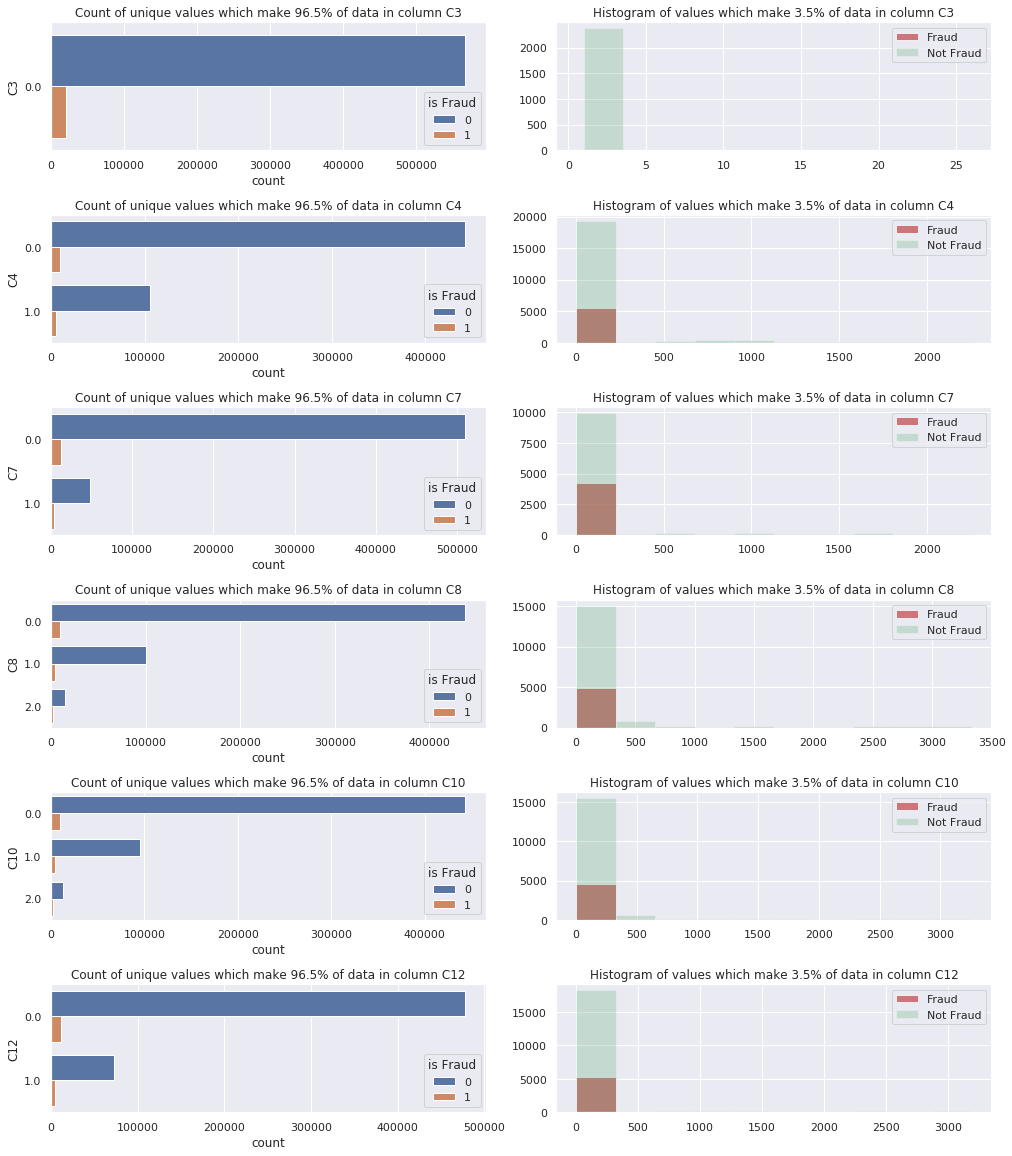

In [23]:
sns.set(rc={'figure.figsize':(14,16)})
x=1
for num, alpha in enumerate(C_cat.col_name):
    plt.subplot(len(C_cat),2,x)
    sns.countplot(data=train_transaction[train_transaction[alpha].isin (C_cat['values_0.96'][num])],y=alpha,hue='isFraud')
    plt.legend(loc='lower right',title='is Fraud')
    plt.title('Count of unique values which make 96.5% of data in column ' + str(alpha) )
    plt.subplot(len(C_cat),2,x+1)
    yes = train_transaction[(train_transaction['isFraud'] == 1) & (train_transaction[alpha].isin (C_cat['values_0.04'][num]))][alpha]
    no = train_transaction[(train_transaction['isFraud'] == 0) & (train_transaction[alpha].isin (C_cat['values_0.04'][num]))][alpha]
    plt.hist(yes, alpha=0.75, label='Fraud', color='r')
    plt.hist(no, alpha=0.25, label='Not Fraud', color='g')
    plt.legend(loc='upper right')
    plt.title('Histogram of values which make 3.5% of data in column ' + str(alpha) )
    x= x+2
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

**Curiously almost 30% of values that fall in the 1% of data in these columns except C3 are part of Fraud transactions**

###### Let's now examine the remaining columns which are numeric in nature.

The graph below shows a histogram of  96.5% of column values on the left and a histogram of remaining 3.5%  values on the right.





In [24]:
C_num = Ccol_details[Ccol_details['num_values_96'] > 15].reset_index()

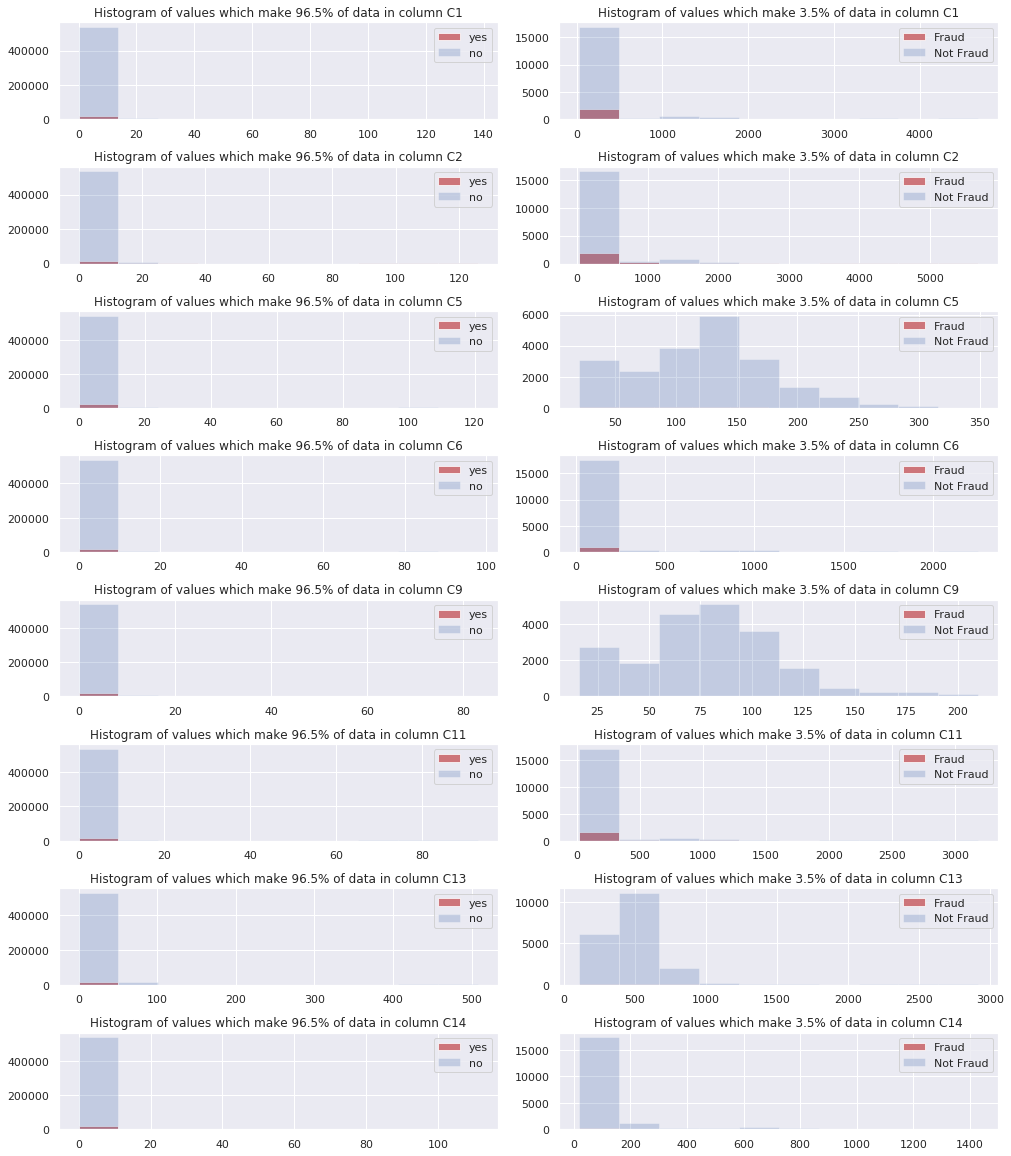

In [25]:
sns.set(rc={'figure.figsize':(14,16)})
x=1
for num, alpha in enumerate(C_num.col_name):
    plt.subplot(len(C_num),2,x)
    yes = train_transaction[(train_transaction['isFraud'] == 1) & (train_transaction[alpha].isin (C_num['values_0.96'][num]))][alpha]
    no = train_transaction[(train_transaction['isFraud'] == 0) & (train_transaction[alpha].isin (C_num['values_0.96'][num]))][alpha]
    plt.hist(yes, alpha=0.75, label='yes', color='r')
    plt.hist(no, alpha=0.25, label='no', color='b')
    plt.legend(loc='upper right')
    plt.title('Histogram of values which make 96.5% of data in column ' + str(alpha) )
    plt.subplot(len(C_num),2,x+1)
    yes = train_transaction[(train_transaction['isFraud'] == 1) & (train_transaction[alpha].isin (C_num['values_0.04'][num]))][alpha]
    no = train_transaction[(train_transaction['isFraud'] == 0) & (train_transaction[alpha].isin (C_num['values_0.04'][num]))][alpha]
    plt.hist(yes, alpha=0.75, label='Fraud', color='r')
    plt.hist(no, alpha=0.25, label='Not Fraud', color='b')
    plt.title('Histogram of values which make 3.5% of data in column ' + str(alpha) )
    plt.legend(loc='upper right')
    x= x+2
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=1.0)

There seem to be no major differnce in proportion of fraud transactions between the two types. However it's interesting to note that the majority of values in these columns are in a narrow range of 0-20  in most of the cases except C13, even though maximum value in these most of columns exceed 3000.